# An attempt to construct a variational autoencoder(based on Troels´ autoencoder example)

In [33]:
import os
import random
import itertools

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights

from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from sklearn import preprocessing, cluster, manifold
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import fetch_openml

import umap

### Data loading

In [34]:
#Getting the images:
unique_path = r"../data\grand_scraper_folder\unique_scrandle_cases_FULL.csv"
unique_dataframe = pd.read_csv(unique_path)
unique_entries = [unique_dataframe["occurrences"][i].split("|")[0].split(" ")[0] + ".webp" for i in range(len(unique_dataframe["occurrences"]))]

#Next, we´ll get the low-res photos imported(doesnt take long. for my computer: 7.5s)

#Creating a list for the photos with the corresponding dates and image names as well(crude way of being able to see which are outliers.
#Needs to be done better, really. If someone has the time, feel free to find a better way of doing things)
image_Data_low_res = []




#Folder with folders of images:
base_folder = r"../data\scrandle_padded_low_res_data"

current_folder = None


#Looping over all dates in the listed directory/folder:
for entry in sorted(unique_entries):
    date, image_placement = entry.split(":")
    
    #Finding a new date folder to check
    date_path = os.path.join(base_folder, date)
    #Checking if the date path exists
    if not os.path.isdir(date_path):
        continue

    print(f"Processing {entry}")
    
    #Reading entry image:
    image_path = os.path.join(date_path, image_placement)
    image_Data_low_res.append({
                    "date": date,
                    "image_name": image_placement,
                    "RGB": plt.imread(image_path, format="webp"),
                })

Processing 2025-04-20:0_left.webp
Processing 2025-04-20:0_right.webp
Processing 2025-04-20:1_left.webp
Processing 2025-04-20:1_right.webp
Processing 2025-04-20:2_left.webp
Processing 2025-04-20:2_right.webp
Processing 2025-04-20:3_left.webp
Processing 2025-04-20:3_right.webp
Processing 2025-04-20:4_left.webp
Processing 2025-04-20:4_right.webp
Processing 2025-04-20:5_left.webp
Processing 2025-04-20:5_right.webp
Processing 2025-04-20:6_left.webp
Processing 2025-04-20:6_right.webp
Processing 2025-04-20:7_left.webp
Processing 2025-04-20:7_right.webp
Processing 2025-04-20:8_left.webp
Processing 2025-04-20:8_right.webp
Processing 2025-04-20:9_left.webp
Processing 2025-04-20:9_right.webp
Processing 2025-04-21:0_left.webp
Processing 2025-04-21:0_right.webp
Processing 2025-04-21:1_left.webp
Processing 2025-04-21:1_right.webp
Processing 2025-04-21:2_left.webp
Processing 2025-04-21:2_right.webp
Processing 2025-04-21:3_left.webp
Processing 2025-04-21:3_right.webp
Processing 2025-04-21:4_left.webp


In [35]:
#Getting only the images:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using Device: {device}")
image_only_low_res = []
for i in range(len(image_Data_low_res)):
    image_only_low_res.append(image_Data_low_res[i]["RGB"])

image_train = torch.from_numpy(np.array(image_only_low_res[:3800])/255).permute(0,3,1,2).float().to(device)
image_test = torch.from_numpy(np.array(image_only_low_res[3800:])/255).permute(0,3,1,2).float().to(device)

Using Device: cpu


In [36]:
#Next, for the dataloader:
class ImageDataset(Dataset):
    def __init__(self, images):
        
        self.images = images

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]

        return image

dataset_train = ImageDataset(image_train)
dataset_test = ImageDataset(image_test)
loader_train = DataLoader(dataset_train, batch_size=80, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=80, shuffle=True)

### Model(Adapted from Troels autoencoder example solution)

In [37]:
class Encoder(nn.Module):
    
    def __init__(self, encoded_space_dim,fc2_input_dim):
        super().__init__()
        
        ### Convolutional section:
        # So we decide to take our 1 input image and first apply 8 kernels/filters of size 3x3
        # with a stride (i.e. step size) of 2 and padding the edge with one layer.
        # This output goes through a ReLU and then through 16 new kernels/filters
        # of the same size, stride and padding, which is then BatchNorm'ed, ReLU'ed, and finally
        # convoluted a third time, again doubling the number of kernels/filters (quite standard!).
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=0),
            nn.ReLU(True),
            nn.Conv2d(8, 16, 3, stride=2, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(True)
        )
        
        ### Flatten layer
        # The images/matrices are then flatten'ed (put into one long array), put through a linear layer,
        # then a ReLU, and then finally another linear layer, which boils it down to the latent space
        # dimension.
        self.flatten = nn.Flatten(start_dim=1)
        ### Linear section
        self.encoder_lin = nn.Sequential(
            nn.Linear(11*9*32, 128),
            nn.ReLU(True),
            nn.Linear(128, encoded_space_dim)
        )
        
    def forward(self, x):
        x = self.encoder_cnn(x)
        x = self.flatten(x)
        x = self.encoder_lin(x)
        return x
    
class Decoder(nn.Module):
    
    def __init__(self, encoded_space_dim,fc2_input_dim):
        super().__init__()
        self.decoder_lin = nn.Sequential(
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 11*9*32),
            nn.ReLU(True)
        )

        ### The decoder does the exact opposite, reconstructing the images from the latent space values.
        self.unflatten = nn.Unflatten(dim=1, 
        unflattened_size=(32, 11, 9))

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=(1,1)),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=0, output_padding=(0,1)),
            nn.BatchNorm2d(8),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 3, 3, stride=2, padding=0, output_padding=(1,0))
        )
        
    def forward(self, x):
        x = self.decoder_lin(x)
        x = self.unflatten(x)
        x = self.decoder_conv(x)
        x = torch.sigmoid(x)
        return x

In [38]:
# Define loss function and training parameters:
# Define the loss function
loss_fn = nn.L1Loss()

# Define an optimizer (both for the encoder and the decoder!)
lr = 0.001

# Set the random seed for reproducible results
torch.manual_seed(42)

# Initialize the two networks
#NOTE: d was initially 4. d=30 works really well!
#NOTE further: There seems to be a sweet spot between 30 and 50.
d = 45
encoder = Encoder(encoded_space_dim=d, fc2_input_dim=128).to(device)
decoder = Decoder(encoded_space_dim=d, fc2_input_dim=128).to(device)
params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()}
]

optim = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-05)
optim

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05
)

In [39]:
#New learning rates:
lr = 0.0001
params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()}
]
#loss_fn = nn.L1Loss()
optim = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-05)
optim

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 1e-05

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 1e-05
)

In [40]:
# Define training and validation functions:

### Training function
def train_epoch(encoder, decoder, dataloader, loss_fn, optimizer):
    # Set train mode for both the encoder and the decoder
    encoder.train()
    decoder.train()
    train_loss = []
    # Iterate the dataloader (we do not need the label values, this is unsupervised learning)
    for image_batch in dataloader: # with "_" we just ignore the labels (the second element of the dataloader tuple)
        # Encode data
        encoded_data = encoder(image_batch)
        # Decode data
        decoded_data = decoder(encoded_data)
        #test = decoded_data.detach().cpu()
        #break
        #Prining the decoded image:
        # Evaluate loss
        loss = loss_fn(decoded_data, image_batch)
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Print batch loss
#         print('\t partial train loss (single batch): %f' % (loss.data))
        train_loss.append(loss.detach().cpu().numpy())

    return np.mean(train_loss)
    #return test


### Testing function
def test_epoch(encoder, decoder, dataloader, loss_fn):
    # Set evaluation mode for encoder and decoder
    encoder.eval()
    decoder.eval()
    with torch.no_grad(): # No need to track the gradients
        # Define the lists to store the outputs for each batch
        conc_out = []
        conc_label = []
        for image_batch in dataloader:
            # Encode data
            encoded_data = encoder(image_batch)
            # Decode data
            decoded_data = decoder(encoded_data)
            # Append the network output and the original image to the lists
            conc_out.append(decoded_data.cpu())
            conc_label.append(image_batch.cpu())
        # Create a single tensor with all the values in the lists
        conc_out = torch.cat(conc_out)
        conc_label = torch.cat(conc_label) 
        # Evaluate global loss
        val_loss = loss_fn(conc_out, conc_label)
    return val_loss.data

In [41]:
# Train the model
num_epochs = 500
diz_loss = {'train_loss':[],'val_loss':[]}
for epoch in range(num_epochs):
    train_loss = train_epoch(encoder,decoder, loader_train, loss_fn, optim)
    val_loss = test_epoch(encoder,decoder,loader_test,loss_fn)
    print('\n EPOCH {}/{} \t train loss {} \t val loss {}'.format(epoch + 1, num_epochs,train_loss,val_loss))
    diz_loss['train_loss'].append(train_loss)
    diz_loss['val_loss'].append(val_loss)


 EPOCH 1/500 	 train loss 0.30263349413871765 	 val loss 0.3069341778755188


KeyboardInterrupt: 

In [42]:
encoder.eval()
decoder.eval()
#Trying to get a reconstructed image:
#reconstruct = (decoder(encoder(images[0].unsqueeze(1).permute(1,0,2,3).to(device))).detach().cpu().numpy()[0]).transpose(1, 2, 0)

Decoder(
  (decoder_lin): Sequential(
    (0): Linear(in_features=45, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=3168, bias=True)
    (3): ReLU(inplace=True)
  )
  (unflatten): Unflatten(dim=1, unflattened_size=(32, 11, 9))
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), output_padding=(0, 1))
    (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(8, 3, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 0))
  )
)

In [44]:

def check_encoder(image_id, train_test):
    reconstruct = decoder(encoder(train_test[image_id].unsqueeze(1).cpu().permute(1,0,2,3).to(device))).detach().cpu().numpy()[0].transpose(1,2,0)
    original = train_test[image_id].cpu().numpy().transpose(1,2,0)
    return reconstruct, original


Showing image comparison for image nr. 1900


<Figure size 1200x12000 with 0 Axes>

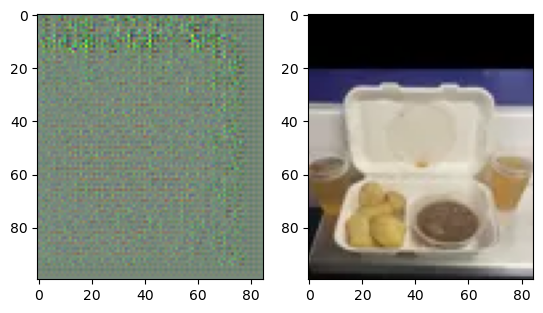

In [45]:
plt.figure(figsize=(12, 120))
random_num = np.random.randint(0, 3799)
image_id = random_num#390
#NOTE: tried running with nearly all data as training data after sending image on discord!
#subplot(r,c) provide the no. of rows and columns
print("Showing image comparison for image nr.", random_num)
f, axarr = plt.subplots(1,2) 

# use the created array to output your multiple images. In this case I have stacked 4 images vertically
axarr[0].imshow(check_encoder(image_id, image_train)[0])
axarr[1].imshow(check_encoder(image_id, image_train)[1])



Showing image comparison for image nr. 63


<Figure size 1200x12000 with 0 Axes>

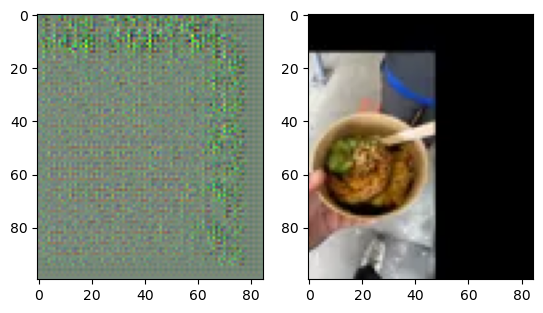

In [46]:
plt.figure(figsize=(12, 120))
random_num2 = np.random.randint(0, len(image_only_low_res[3800:]))
image_id = random_num2
print("Showing image comparison for image nr.", random_num2)
#NOTE: tried running with nearly all data as training data after sending image on discord!
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1,2) 

# use the created array to output your multiple images. In this case I have stacked 4 images vertically
axarr[0].imshow(check_encoder(image_id, image_test)[0])
axarr[1].imshow(check_encoder(image_id, image_test)[1])

### Here follows some models that were tested, but deemed bad for now:

In [47]:
#Original, but with dropout layers:
class Encoder(nn.Module):
    
    def __init__(self, encoded_space_dim,fc2_input_dim):
        super().__init__()
        
        ### Convolutional section:
        # So we decide to take our 1 input image and first apply 8 kernels/filters of size 3x3
        # with a stride (i.e. step size) of 2 and padding the edge with one layer.
        # This output goes through a ReLU and then through 16 new kernels/filters
        # of the same size, stride and padding, which is then BatchNorm'ed, ReLU'ed, and finally
        # convoluted a third time, again doubling the number of kernels/filters (quite standard!).
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=0),
            nn.ReLU(True),
            nn.Dropout(p=0.5, inplace=False),
            nn.Conv2d(8, 16, 3, stride=2, padding=0),
            nn.BatchNorm2d(16),
            nn.Dropout(p=0.2, inplace=False),
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(True)
        )
        
        ### Flatten layer
        # The images/matrices are then flatten'ed (put into one long array), put through a linear layer,
        # then a ReLU, and then finally another linear layer, which boils it down to the latent space
        # dimension.
        self.flatten = nn.Flatten(start_dim=1)
        ### Linear section
        self.encoder_lin = nn.Sequential(
            nn.Linear(11*9*32, 128),
            nn.ReLU(True),
            nn.Linear(128, encoded_space_dim)
        )
        
    def forward(self, x):
        x = self.encoder_cnn(x)
        x = self.flatten(x)
        x = self.encoder_lin(x)
        return x
    
class Decoder(nn.Module):
    
    def __init__(self, encoded_space_dim,fc2_input_dim):
        super().__init__()
        self.decoder_lin = nn.Sequential(
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 11*9*32),
            nn.ReLU(True)
        )

        ### The decoder does the exact opposite, reconstructing the images from the latent space values.
        self.unflatten = nn.Unflatten(dim=1, 
        unflattened_size=(32, 11, 9))

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=(1,1)),
            nn.BatchNorm2d(16),
            nn.Dropout(p=0.2, inplace=False),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=0, output_padding=(0,1)),
            nn.BatchNorm2d(8),
            nn.Dropout(p=0.2, inplace=False),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 3, 3, stride=2, padding=0, output_padding=(1,0))
        )
        
    def forward(self, x):
        x = self.decoder_lin(x)
        x = self.unflatten(x)
        x = self.decoder_conv(x)
        x = torch.sigmoid(x)
        return x

In [48]:
#New one. Here, so i can experiment untill it works, but its always possible to go back:
class Encoder(nn.Module):
    
    def __init__(self, encoded_space_dim,fc2_input_dim):
        super().__init__()
        
        ### Convolutional section:
        # So we decide to take our 1 input image and first apply 8 kernels/filters of size 3x3
        # with a stride (i.e. step size) of 2 and padding the edge with one layer.
        # This output goes through a ReLU and then through 16 new kernels/filters
        # of the same size, stride and padding, which is then BatchNorm'ed, ReLU'ed, and finally
        # convoluted a third time, again doubling the number of kernels/filters (quite standard!).
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=0),
            nn.ReLU(True),
            nn.Conv2d(8, 16, 3, stride=2, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(True),
            nn.Conv2d(32, 32, 3, stride=3, padding=0),
            nn.ReLU(True)
        )
        
        ### Flatten layer
        # The images/matrices are then flatten'ed (put into one long array), put through a linear layer,
        # then a ReLU, and then finally another linear layer, which boils it down to the latent space
        # dimension.
        self.flatten = nn.Flatten(start_dim=1)
        ### Linear section
        self.encoder_lin = nn.Sequential(
            nn.Linear(3*3*32, 128),
            nn.ReLU(True),
            nn.Linear(128, encoded_space_dim)
        )
        
    def forward(self, x):
        x = self.encoder_cnn(x)
        x = self.flatten(x)
        x = self.encoder_lin(x)
        return x
    
class Decoder(nn.Module):
    
    def __init__(self, encoded_space_dim,fc2_input_dim):
        super().__init__()
        self.decoder_lin = nn.Sequential(
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 3*3*32),
            nn.ReLU(True)
        )

        ### The decoder does the exact opposite, reconstructing the images from the latent space values.
        self.unflatten = nn.Unflatten(dim=1, 
        unflattened_size=(32, 3, 3))

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 32, 3, stride=3, padding=(0,0), output_padding=(2,0)),
            nn.BatchNorm2d(32),
            nn.Dropout(p=0.2, inplace=False),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=(0,0), output_padding=(1,1)),
            nn.BatchNorm2d(16),
            nn.Dropout(p=0.2, inplace=False),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=(0,0), output_padding=(0,1)),
            nn.BatchNorm2d(8),
            nn.Dropout(p=0.2, inplace=False),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 3, 3, stride=2, padding=(0,0), output_padding=(1,0))
        )
        
    def forward(self, x):
        x = self.decoder_lin(x)
        x = self.unflatten(x)
        x = self.decoder_conv(x)
        x = torch.sigmoid(x)
        return x

### Now to try to get ResNet to work:

In [49]:
# RESNET FRON HERE

# Done with respcect to the 100x85 pictures  : ()
class Decoder_RN(nn.Module):
    """
    Decoder that reconstructs images from latent vectors.

    latent →
      FC expansion →
        reshape →
          ConvTranspose
    """

    def __init__(self, encoded_space_dim):
        super().__init__()

        # Expand latent vector → feature map
        self.decoder_lin = nn.Sequential(
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),

            # nn.Linear(128, 256 * 4 * 4), # OLD: produced 32x32 output
            nn.Linear(128, 256 * 6 * 5),   # NEW: start from bigger feature map (~better resolution)
            nn.ReLU(True)
        )

        # Reshape to (channels, height, width)
        self.unflatten = nn.Unflatten(
            dim=1,
            # unflattened_size=(256, 4, 4) # OLD
            unflattened_size=(256, 6, 5)   # NEW: matches updated linear layer
        )

        # Upsampling pipeline
        # Padding of 1 used everywhere.
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),  # 6x5 → 12x10
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),   # 12x10 → 24x20
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),    # 24x20 → 48x40
            nn.ReLU(True),

            # ADDITIONAL UPSAMPLING STEP (NEW)
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),    # 48x40 → 96x80
            nn.ReLU(True),

            nn.ConvTranspose2d(16, 3, 3, stride=1, padding=1)      # RGB
        )

    def forward(self, x):
        x = self.decoder_lin(x)     
        x = self.unflatten(x)       
        x = self.decoder_conv(x)    
        x = torch.sigmoid(x)        
        return x  # now outputs ~96x80 images (closer to your 100x85)


In [50]:
#Size of latent space, tune it.
d = 30   

# Choose GPU if Christopher, otherwise CPU at weak Ulle.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize encoder (image → latent vector of dim d)
encoder = RN_encoder(d).to(device)

# Initialize decoder (latent vector → reconstructed image) this is the reverse funnel.
rn_decoder = Decoder_RN(d).to(device)

# Combine parameters from BOTH models
# → optimizer will update both encoder and decoder during training
params_to_optimize = list(encoder.parameters()) + list(rn_decoder.parameters())

# Adam optimizer (standard for deep learning)
optim = torch.optim.Adam(
    params_to_optimize,
    lr=1e-3,          # learning rate (step size) #tune this maybe.
    weight_decay=1e-5 # L2 regularization (should prevent overfitting.)
)

In [51]:
# ALL OF THIS IS JUST A SANITY CHECK

# Dummy input: batch of 2 RGB images, size 224x224
# (ResNet expects 224x224 input)
x = torch.randn(2, 3, 224, 224).to(device)

# Encode: image → latent vector (compressed representation)
z = encoder(x)

# Decode: latent vector → reconstructed image
out = rn_decoder(z)

# Print shapes to verify everything works correctly

# Expected: (batch_size, latent_dim)
# = (2, 30)
print(z.shape)

# Expected: (batch_size, channels, height, width)
# OLD: (2, 3, 32, 32)
# NEW: (2, 3, ~96, ~80)  ← due to improved decoder design
print(out.shape)



torch.Size([2, 30])
torch.Size([2, 3, 96, 80])


In [52]:
def rn_train_epoch(encoder, decoder, dataloader, loss_fn, optimizer, device):
    # Set both models to training mode (important for BatchNorm, Dropout, etc.)
    encoder.train()
    decoder.train()

    train_loss = [] 

    # Loop over batches from dataloader
    for image_batch in dataloader:

        # Move batch to GPU/CPU (Poor poor Ulle)
        image_batch = image_batch.to(device)

        encoded_data = encoder(image_batch)  # use of Encoder

        decoded_data = decoder(encoded_data)  # use of Decoder

        # Ensure output image has same size as input 
        # OLD: decoder gave 32x32 → large upscaling (bad)
        # NEW: decoder gives ~96x80 → only small resize needed (much better)
        if decoded_data.shape != image_batch.shape:  # only if sizes do not match
            decoded_data = torch.nn.functional.interpolate(
                decoded_data,
                size=image_batch.shape[-2:],  # match height & width
                mode="bilinear"               # smoother resizing (better than default)
            )  # https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.interpolate.html


        # Compute reconstruction loss (e.g. MSE between input and output)
        loss = loss_fn(decoded_data, image_batch)

        # Backpropagation step
        optimizer.zero_grad()  # reset gradients
        loss.backward()        # compute gradients
        optimizer.step()       # update weights

        # Store loss value for tracking
        train_loss.append(loss.item())

    # Return average loss from the epoch
    return sum(train_loss) / len(train_loss)

In [53]:
def rn_test_epoch(encoder, decoder, dataloader, loss_fn, device):  # THIS IS LE TESTEER
    # Set models to evaluation mode
    # → disables dropout, uses running stats for BatchNorm
    encoder.eval()
    decoder.eval()

    # No gradients needed → saves memory and is faster
    with torch.no_grad():

        losses = []

        # Loop over validation/test data
        for image_batch in dataloader:

            # Move data to correct device
            image_batch = image_batch.to(device)

            # Forward pass (same as training, but no gradient tracking here)
            encoded_data = encoder(image_batch)   # image → latent
            decoded_data = decoder(encoded_data)  # latent → reconstruction

            # Ensure output size matches input size
            # OLD: 32x32 → big resize
            # NEW: ~96x80 → small correction (better quality)
            if decoded_data.shape != image_batch.shape:
                decoded_data = torch.nn.functional.interpolate(
                    decoded_data,
                    size=image_batch.shape[-2:],  # match height & width
                    mode="bilinear"               # smoother resizing
                )

            # Compute reconstruction loss
            loss = loss_fn(decoded_data, image_batch)

            # Store loss
            losses.append(loss.item())

    # Return average loss over dataset
    return sum(losses) / len(losses)

In [54]:
# Number of full passes through the dataset
num_epochs = 20

# Dictionary to track loss over time
diz_loss = {
    'train_loss': [],
    'val_loss': []
} #You may plot thises later.

# Main training loop
for epoch in range(num_epochs):
    # Run one full training epoch
    # updates model weights
    train_loss = rn_train_epoch(
        encoder,
        rn_decoder,
        loader_train,
        loss_fn,
        optim,
        device
    )

    # Run one full validation epoch
    #NO weight updates, only evaluation. 
    val_loss = rn_test_epoch(
        encoder,
        rn_decoder,
        loader_test,
        loss_fn,
        device
    )

    # Print progress for monitoring training, yesyesyes.
    print(
        f"EPOCH {epoch+1}/{num_epochs} "
        f"\t train {train_loss:.4f} "
        f"\t val {val_loss:.4f}"
    )

    # Store losses for later analysis (e.g. plotting)
    diz_loss['train_loss'].append(train_loss)
    diz_loss['val_loss'].append(val_loss)

EPOCH 1/20 	 train 0.2022 	 val 0.1535
EPOCH 2/20 	 train 0.1447 	 val 0.1320
EPOCH 3/20 	 train 0.1298 	 val 0.1206
EPOCH 4/20 	 train 0.1232 	 val 0.1167
EPOCH 5/20 	 train 0.1192 	 val 0.1129
EPOCH 6/20 	 train 0.1153 	 val 0.1121
EPOCH 7/20 	 train 0.1131 	 val 0.1081
EPOCH 8/20 	 train 0.1107 	 val 0.1051
EPOCH 9/20 	 train 0.1082 	 val 0.1048
EPOCH 10/20 	 train 0.1065 	 val 0.1059
EPOCH 11/20 	 train 0.1062 	 val 0.1012
EPOCH 12/20 	 train 0.1041 	 val 0.1012
EPOCH 13/20 	 train 0.1027 	 val 0.1004
EPOCH 14/20 	 train 0.1014 	 val 0.0995
EPOCH 15/20 	 train 0.0999 	 val 0.0992
EPOCH 16/20 	 train 0.1001 	 val 0.0976
EPOCH 17/20 	 train 0.0983 	 val 0.0972
EPOCH 18/20 	 train 0.0989 	 val 0.0993
EPOCH 19/20 	 train 0.0979 	 val 0.0973
EPOCH 20/20 	 train 0.0979 	 val 0.0971


In [57]:
def check_resnet(image_id, dataset): #THis is le evalueation.
    # Set models to evaluation mode (no dropout / stable BatchNorm)
    encoder.eval()
    rn_decoder.eval()

    # No gradients needed → faster + less memory
    with torch.no_grad():

        # Get single image from dataset
        # Add batch dimension → (1, 3, H, W)
        img = dataset[image_id].unsqueeze(0).to(device)

        # Forward pass:
        # image → encoder → latent → decoder → reconstruction
        reconstructed = rn_decoder(encoder(img))

        # Ensure reconstructed image has same size as original
        if reconstructed.shape != img.shape:
            reconstructed = torch.nn.functional.interpolate(
                reconstructed,
                size=img.shape[-2:]  # match height & width
            )

        # Convert tensors → numpy arrays for plotting
        # Also reshape from (C, H, W) → (H, W, C)
        reconstructed = reconstructed.squeeze(0).cpu().numpy().transpose(1, 2, 0)
        original = img.squeeze(0).cpu().numpy().transpose(1, 2, 0)

    # Return both images for comparison
    return reconstructed, original


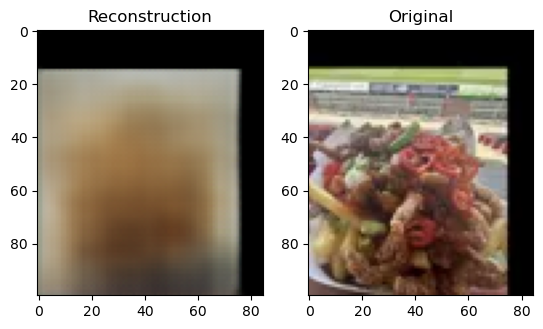

In [58]:
recon, orig = check_resnet(50, image_train)

plt.subplot(1,2,1)
plt.title("Reconstruction")
plt.imshow(recon)

plt.subplot(1,2,2)
plt.title("Original")
plt.imshow(orig)